# Quality Assurance

<a target="_blank" href="https://colab.research.google.com/github/zentralbibliothek-zuerich/zblab-summerschool-2026/blob/main/notebooks/02_quality_assurance.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a> 

This notebook contains boilerplate code that you don't need to interact with directly.

The sections where you can safely experiment or customize are clearly marked with such comments:

```python
# ⬇️⬇️⬇️
YOUR_INPUT = ""
# ⬆️⬆️⬆️
```

## Setup

### Housekeeping (no interaction required)

In [1]:
%pip install "impresso_pipelines[ocrqa]"

/home/bode-wsl/projects/summerschool26/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


❗ Please restart the kernel/runtime after installing the package to ensure that all changes take effect.

(Google Colab might initiate a restart on its own)

In [ ]:
import os
from pathlib import Path
import textwrap
from typing import Literal

import pandas as pd
from tqdm.notebook import tqdm

In [4]:
IN_COLAB = 'COLAB_RELEASE_TAG' in os.environ
DATA_DIR = Path('/content/drive/MyDrive/ZBLabSummerSchool2026/data') if IN_COLAB else Path('../data')

### Setup (interaction required)

In [ ]:
### ⬇️⬇️⬇️  Adjust here if you want to load the data from your google drive
CORPUS_NAME = "armenpflege"
USE_YOUR_DATA = False
### ⬆️⬆️⬆️

## Load the data

### <img src="https://cdn.svglogos.dev/logos/google-drive.svg" alt="💾" width=16> Load your own data from Google Drive

<img src="https://cdn.svglogos.dev/logos/google-drive.svg" alt="💾" width=12> The cell below will attempt to connect to your Google Drive.

*Once prompted, give all demanded permissions*

In [6]:
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    os.makedirs(DATA_DIR, exist_ok=True)

In [ ]:
if USE_YOUR_DATA:
    RAWDATA_PATH = DATA_DIR / f"{CORPUS_NAME}.full.parquet" 
    raw_df = pd.read_parquet(RAWDATA_PATH)
    # RAWDATA_PATH = DATA_DIR / f"{CORPUS_NAME}.raw.csv" 
    # raw_df = pd.read_csv(RAWDATA_PATH, index_col="id")

### <img src="https://www.zb.uzh.ch/themes/zb/assets/images/favicon-192.png" alt="💾" width=16> Load from example

In [ ]:
if not USE_YOUR_DATA:
    RAWDATA_URL = f"https://media.githubusercontent.com/media/zentralbibliothek-zuerich/zblab-summerschool-2026/main/data/armenpflege.full.parquet"
    raw_df = pd.read_parquet(RAWDATA_URL)

    #RAWDATA_ORIGIN_URL = "https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/armensteuer_and_similars.01.parquet" 
    #raw_df = pd.read_parquet(RAWDATA_ORIGIN_URL)

### Parsing and preparing

For easier handling, the cell below extracts only the year from the complex date column.

`1880-03-07T00:00:00+00:00` ➡️ `1880`


In [9]:
raw_df["year"] = pd.to_datetime(raw_df["date"]).dt.year

## OCR quality assessment

In [10]:
from impresso_pipelines.ocrqa import OCRQAPipeline

In [11]:
ocrqa_pipeline = OCRQAPipeline()

In [ ]:
def assess_quality(s: str) -> float:
    qa = ocrqa_pipeline(s, language="de")
    return qa["score"]

tqdm.pandas(desc="Assessing OCR quality")
raw_df["ocr_quality"] = raw_df["content"].progress_apply(assess_quality)

## Inspect the quality

### OCR quality distribution over time

In [13]:
import numpy as np

# Define number of tiers
N = 10
bins = np.linspace(0, 1, N + 1)
tier_labels = [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(N)]

raw_df["quality_tier"] = pd.cut(
    raw_df["ocr_quality"],
    bins=bins.tolist(),
    labels=tier_labels,
    include_lowest=True
)

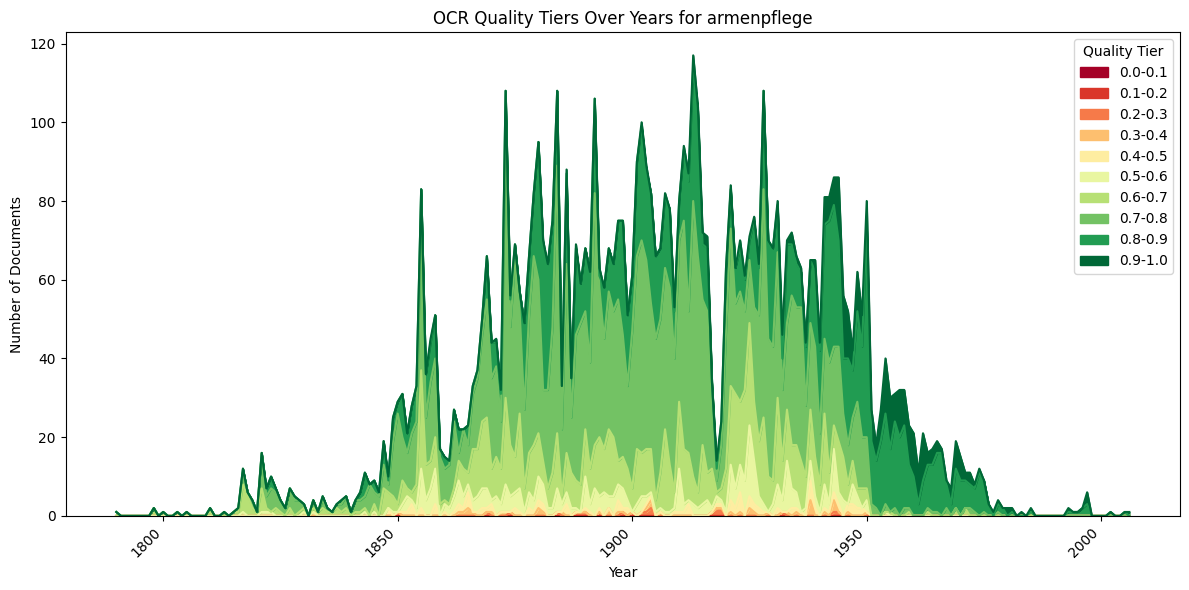

In [ ]:
import matplotlib.pyplot as plt

def plot_quality_tiers_over_time(df: pd.DataFrame):
    df = df.copy()

    # Group by year and quality tier, then count occurrences
    df_grouped = df.groupby(['year', 'quality_tier'], observed=False).size().unstack(fill_value=0)
    full_index = range(df_grouped.index.min(), df_grouped.index.max() + 1)
    df_grouped = df_grouped.reindex(full_index, fill_value=0)

    cmap = plt.cm.RdYlGn
    colors = {label: cmap(i / (N - 1)) for i, label in enumerate(tier_labels)}

    # Plot the stacked bar chart
    ax = df_grouped.plot(kind='area', stacked=True, figsize=(12, 6),
                            color=[colors[col] for col in df_grouped.columns]
    )

    # Add title and labels
    plt.title(f'OCR Quality Tiers Over Years for {CORPUS_NAME}')
    plt.xlabel('Year')
    plt.ylabel('Number of Documents')
    plt.legend(title='Quality Tier')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

plot_quality_tiers_over_time(raw_df)

### Inspect examples of quality tiers

In [16]:
unique_quality_tiers = raw_df['quality_tier'].unique()

for tier in sorted(unique_quality_tiers):
    # Filter the DataFrame for the current tier
    tier_df = raw_df[raw_df['quality_tier'] == tier]

    # Select a random example from the filtered DataFrame
    if not tier_df.empty:
        example = tier_df.sample(1).iloc[0]
        print(f"OCR Quality Score: {example['ocr_quality']:.2f}")
        print(textwrap.fill(example['content'][:500], width=80)) # Wrap content for display
        print()

OCR Quality Score: 0.27
pie pdiknjr » an UtJaltiedtHati ( Trau 3 n einer ber Iejjten © ettatsfifeungen
tjielt SBalbed 9 touffeau feit feinem Siiicitritt bon ber Regierung jutn erften
9 Jtet roieber eine Siebe. © iefelbe tjat gewaltiges auftreten erregt, roeil fte
eine Verurteilung ber © ombeSfdjen 33 olitil roar. Stuf ber SageSorbnung ftanb
ber ( Scfejj. entrottrf über ben « Bau neuer © djultjäufer. Öufjer bem
ftaupteinroanbe, ber audj in berföatnmer gegen baS © efefc erboten rourbe bie
Dpf: r, bie tl ben © emeinben au

OCR Quality Score: 0.32
Armenpflege. Wohltätigkeits Büreau. In de» Wirlur.oelrcis der Nobllbatigleils-
Bureaus, der ibm durch dos Ges tz angewicso» ist, getfren eiun-sciis dic
Schoshtiig gcsctzlicher SDïittcl, uni sich dos ersordcrliche Auekommen zu
sicher» und anderscits die wohlvcrstandcne Auslbeilung der Uiilersliit'ungen.
Die Miitel, wclchc fiir das Iahr 1865 dem Wohl> thoiigleiii-Vui-caii ziii
Vcriiigung nngcwicfcn odcr von ibm wordcn sind, bcstondeu aus solgendcn,

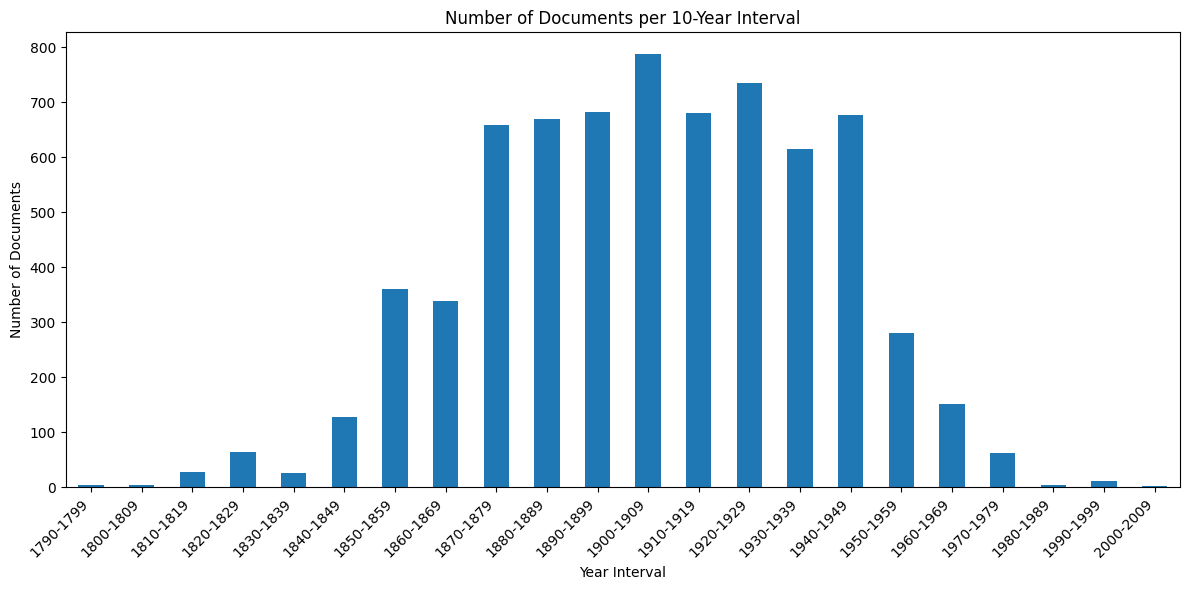

In [ ]:
def plot_documents_per_year_intervals(
    df: pd.DataFrame,
    n_years: int,
    group: Literal["media_title", "country_code", "province_code"] | None = None,
):
    df = df.copy()
    start = (df["year"].min() // n_years) * n_years
    end = (df["year"].max() // n_years + 1) * n_years

    # Include the final bin edge so the newest interval is not dropped.
    bins = range(start, end + 1, n_years)
    labels = [f"{b}-{b+n_years-1}" for b in bins[:-1]]
    df["year_interval"] = pd.cut(df["year"], bins=bins, labels=labels, include_lowest=True)

    fig, ax = plt.subplots(figsize=(12, 6))

    if group is None:
        # Un-grouped view.
        df.groupby("year_interval", observed=False).size().plot(kind="bar", ax=ax)
        ax.set_title(f"Number of Documents per {n_years}-Year Interval")
    else:
        # Grouped view: keep top 5 categories and collapse the rest into "Other".
        top_groups = df[group].value_counts().nlargest(5).index
        df[group] = df[group].where(df[group].isin(top_groups), other="Other")
        (
            df.groupby(["year_interval", group], observed=False)
            .size()
            .unstack(fill_value=0)
            .plot(kind="bar", stacked=True, ax=ax)
        )
        ax.set_title(f"Number of Documents per {n_years}-Year Interval and {group}")
        ax.legend(title=group)

    ax.set_xlabel("Year Interval")
    ax.set_ylabel("Number of Documents")
    ax.tick_params(axis="x", rotation=45)
    plt.setp(ax.get_xticklabels(), ha="right")
    fig.tight_layout()
    plt.show()

In [ ]:
# ⬇️⬇️⬇️ Change the n_years to see how different bucketing affects possible conclusions
plot_documents_per_year_intervals(raw_df, n_years=10)
# ⬆️⬆️⬆️

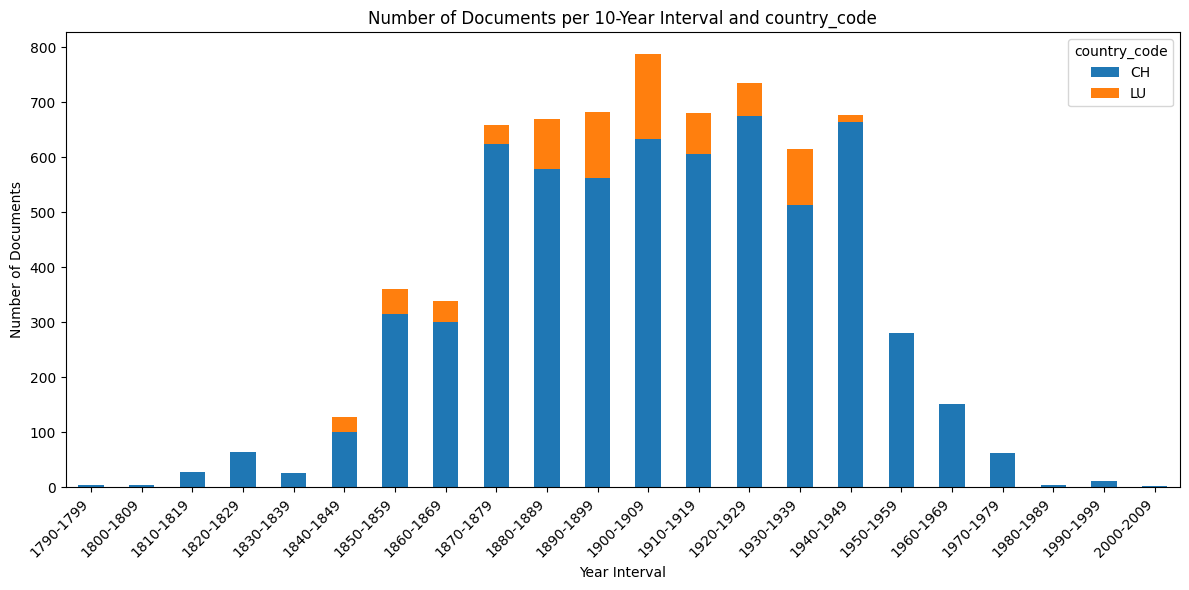

In [34]:
# ⬇️⬇️⬇️
plot_documents_per_year_intervals(raw_df, n_years=10, group="media_title")
# ⬆️⬆️⬆️

In [ ]:
# ⬇️⬇️⬇️
plot_documents_per_year_intervals(raw_df, n_years=10, group="province_code")
# ⬆️⬆️⬆️

In [ ]:
# ⬇️⬇️⬇️
plot_documents_per_year_intervals(raw_df, n_years=10, group="country_code")
# ⬆️⬆️⬆️

## Filter corpus

### Apply filter

In [39]:
# ⬇️⬇️⬇️
QUALITY_CUTOFF = 0.8
# ⬆️⬆️⬆️

df_filtered = raw_df[raw_df["ocr_quality"] >= QUALITY_CUTOFF]

### Inspect remaining data

Check how much of the full corpus remains.
Is it enough for your research questions?

You might need to find a compromise between your ideals and the potential for certain analyses. 

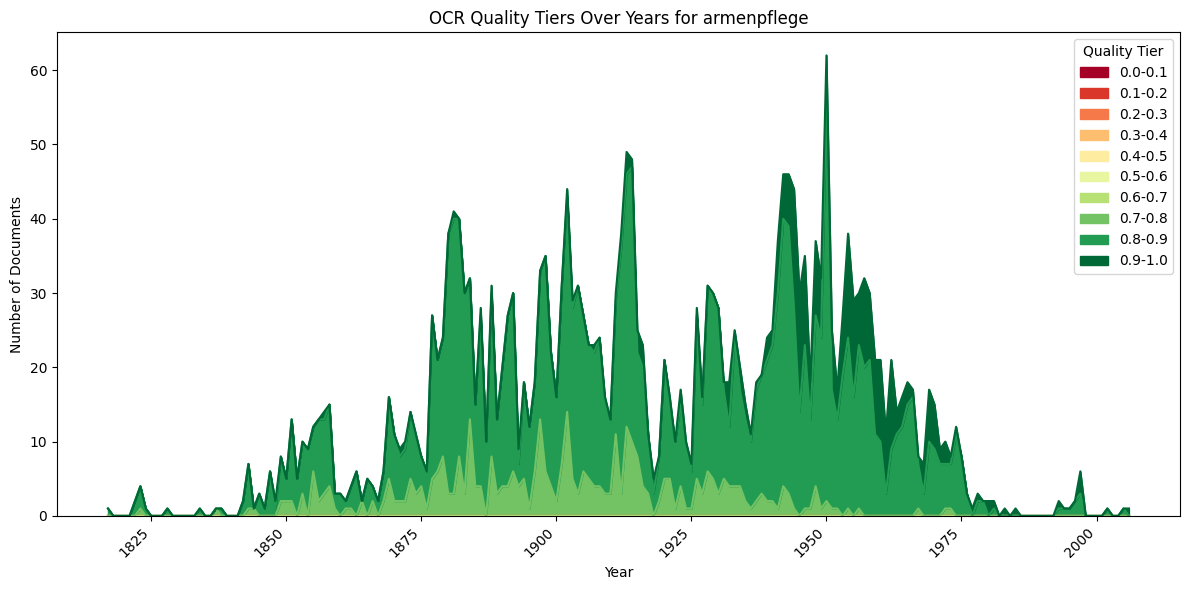

In [40]:
plot_quality_tiers_over_time(df_filtered)

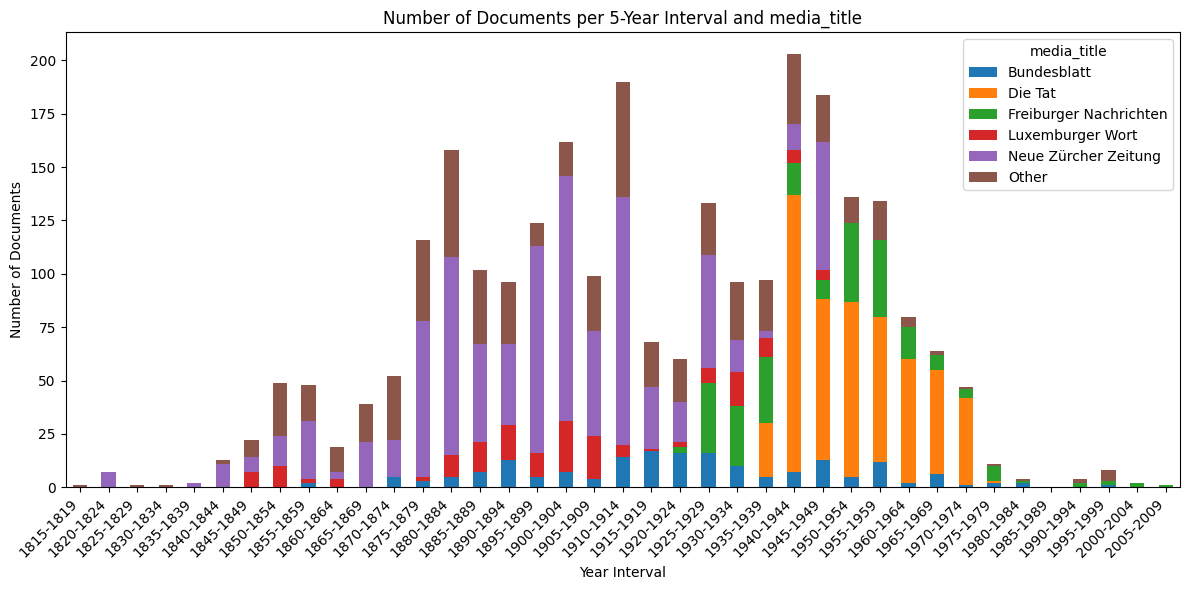

In [43]:
plot_documents_per_year_intervals(df_filtered, n_years=5, group="media_title")

### Save the filtered corpus

In [ ]:
if USE_YOUR_DATA:
    df_filtered = df_filtered.drop(columns=["quality_tier", "year"])
    df_filtered.to_parquet(DATA_DIR / f"{CORPUS_NAME}.filtered.parquet")
    print(f"Filtered data saved to {DATA_DIR / f'{CORPUS_NAME}.filtered.parquet'}")
    print(f"Lowest quality score in filtered data: {df_filtered['ocr_quality'].min():.2f}")

Filtered data saved to ../data/armenpflege.filtered.parquet
Lowest quality score in filtered data: 0.80
